## Avance 3 - Análisis Integrado y Visualizaciones
#### Objetivos: Cruzar datos de clientes con información de restaurantes Yelp, identificar patrones de consumo y preferencias, y generar insights accionables para marketing.

#### Visualizaciones principales: Diagrama de barras de personas por ciudad; listado de distribución por estratos socioeconómicos; ciudades con mayor gasto promedio; relación frecuencia de visita vs gasto por estrato; dispersión gasto mensual vs ingresos; distribución de preferencias alimenticias por ciudad; perfilamiento de clientes de mayor gasto; análisis de membresías por ciudad; consumo de alcohol vs edad.

In [1]:
#Vamos a por las librerias que seguro usaremos en este tercer avance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualizaciones
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Arrancamos cargando los archivos a trabajar

# Leer CSV completo desde Drive
url_drive = "https://drive.google.com/uc?id=1VMmmmmXpOsA_nm220fVqM4AVtE-9NjuJ&export=download"
df_clientes_completo = pd.read_csv(url_drive)

# Clientes de Chicago procesados (Avance 1)
df_clientes_chicago = pd.read_csv("../Archivos_CSV/clientes_chicago_procesado.csv")

# Restaurantes con estrato (Avance 2)
df_restaurantes = pd.read_csv("../Archivos_CSV/restaurantes_chicago_yelp.csv")

print(f"Clientes completos (todas ciudades): {df_clientes_completo.shape}")
print(f"Clientes Chicago (procesados): {df_clientes_chicago.shape}")
print(f"Restaurantes Chicago: {df_restaurantes.shape}")

Clientes completos (todas ciudades): (30000, 17)
Clientes Chicago (procesados): (5069, 16)
Restaurantes Chicago: (200, 18)


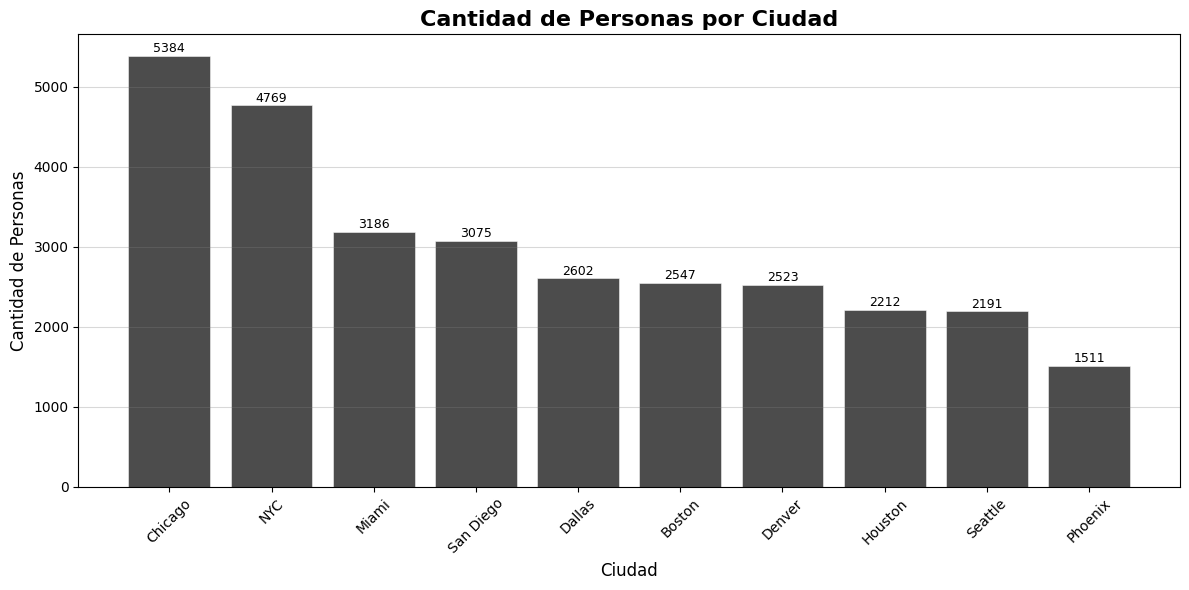

 - Total ciudades en dataset: 10
 - Ciudad con más personas: Chicago (5384 personas)
 - Chicago posición: 1°


In [3]:
# Analisis Demografico
# Diagrama de barras: Personas por ciudad 
# Objetivo: Visualizar la distribución de personas en las diferentes ciudades para entender la representatividad de Chicago en el dataset completo.

plt.figure(figsize=(12, 6))
personas_por_ciudad = df_clientes_completo['ciudad_residencia'].value_counts()

# Gráfico en blanco y negro - mostrando todas las ciudades
bars = plt.bar(range(len(personas_por_ciudad)), personas_por_ciudad.values, 
               color='black', alpha=0.7, edgecolor='white', linewidth=0.5)

plt.title('Cantidad de Personas por Ciudad', fontsize=16, fontweight='bold', color='black')
plt.xlabel('Ciudad', fontsize=12, color='black')
plt.ylabel('Cantidad de Personas', fontsize=12, color='black')

# Configurar ejes en blanco y negro
plt.xticks(range(len(personas_por_ciudad)), personas_por_ciudad.index, rotation=45, color='black')
plt.yticks(color='black')
plt.gca().set_facecolor('white')
plt.grid(axis='y', alpha=0.3, color='gray')

# Añadir valores en las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()

print(f" - Total ciudades en dataset: {df_clientes_completo['ciudad_residencia'].nunique()}")
print(f" - Ciudad con más personas: {personas_por_ciudad.idxmax()} ({personas_por_ciudad.max()} personas)")
print(f" - Chicago posición: {list(personas_por_ciudad.index).index('Chicago') + 1}°")

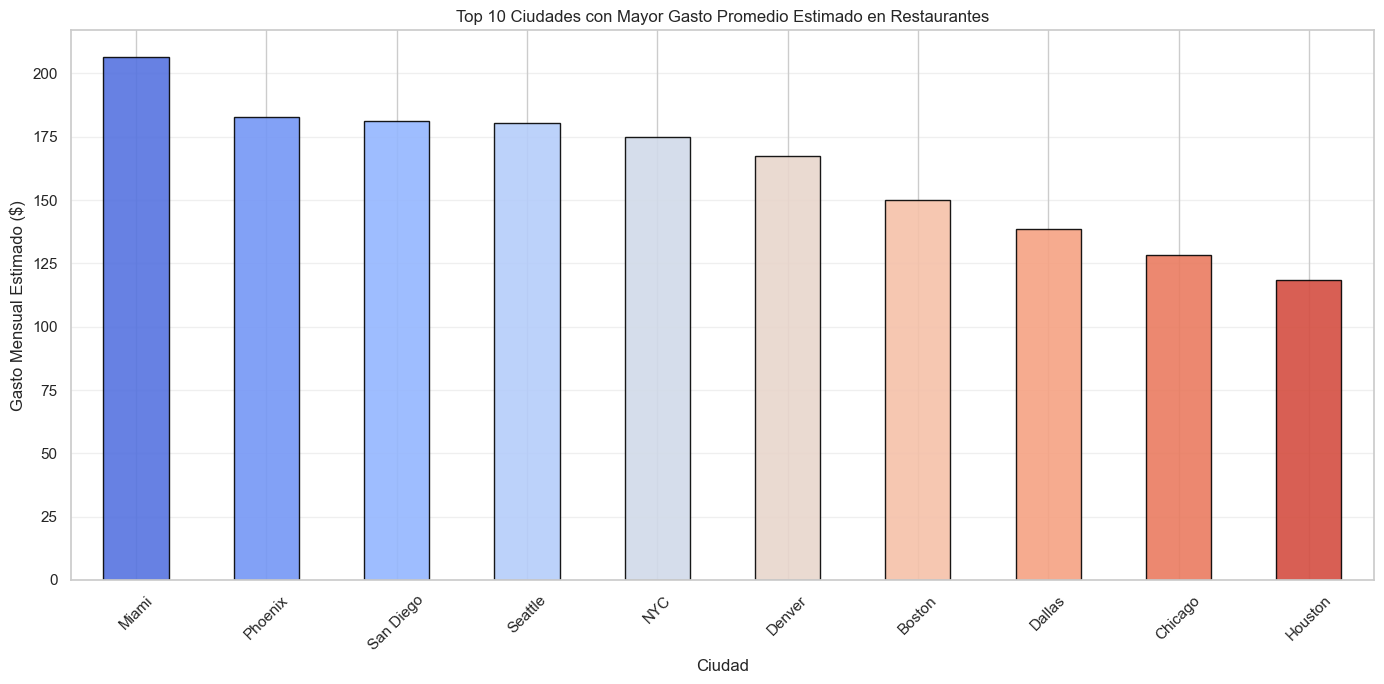

In [10]:
# Calcular gasto promedio por ciudad (usando promedio_gasto_comida * frecuencia_visita como proxy)
df_clientes_completo['gasto_mensual_estimado'] = df_clientes_completo['promedio_gasto_comida'] * df_clientes_completo['frecuencia_visita']

gasto_por_ciudad = df_clientes_completo.groupby('ciudad_residencia')['gasto_mensual_estimado'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Colores llamativos con degradado
palette = sns.color_palette("coolwarm", n_colors=10)

# Grafico
ax = gasto_por_ciudad.head(10).plot(
    kind='bar',
    color=palette,
    alpha=0.9,
    edgecolor='black'
)
plt.title('Top 10 Ciudades con Mayor Gasto Promedio Estimado en Restaurantes')
plt.ylabel('Gasto Mensual Estimado ($)')
plt.xlabel('Ciudad')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

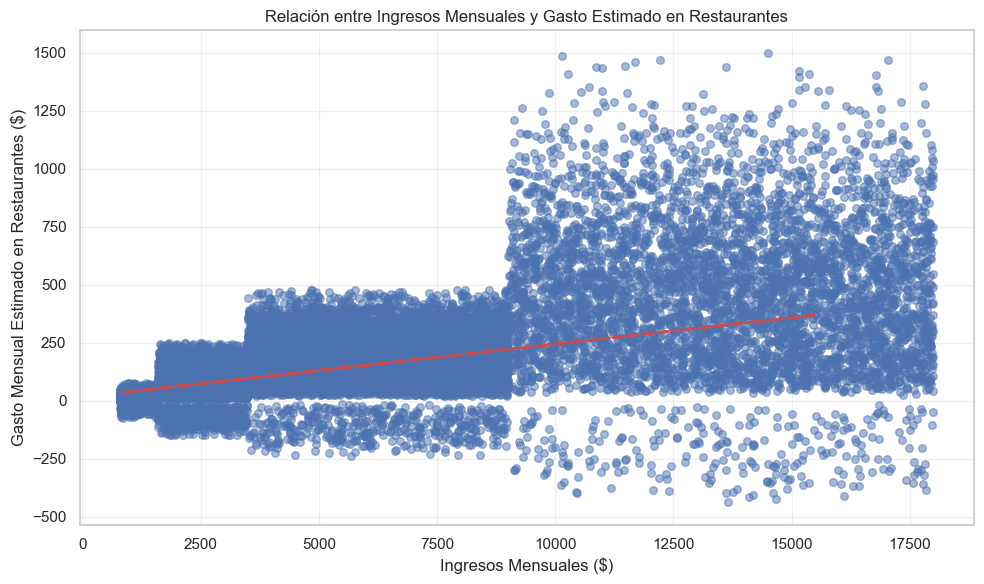

In [11]:
# Relacion entre gasto mensual e ingresos mensuales
plt.figure(figsize=(10, 6))
plt.scatter(df_clientes_completo['ingresos_mensuales'], 
           df_clientes_completo['gasto_mensual_estimado'], 
           alpha=0.5, s=30)

# Calcular linea de tendencia (excluyendo outliers)
df_filtrado = df_clientes_completo[(df_clientes_completo['ingresos_mensuales'] < df_clientes_completo['ingresos_mensuales'].quantile(0.95)) &
                                  (df_clientes_completo['gasto_mensual_estimado'] < df_clientes_completo['gasto_mensual_estimado'].quantile(0.95))]

z = np.polyfit(df_filtrado['ingresos_mensuales'], df_filtrado['gasto_mensual_estimado'], 1)
p = np.poly1d(z)
plt.plot(df_filtrado['ingresos_mensuales'], p(df_filtrado['ingresos_mensuales']), "r--", linewidth=2)

plt.title('Relación entre Ingresos Mensuales y Gasto Estimado en Restaurantes')
plt.xlabel('Ingresos Mensuales ($)')
plt.ylabel('Gasto Mensual Estimado en Restaurantes ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

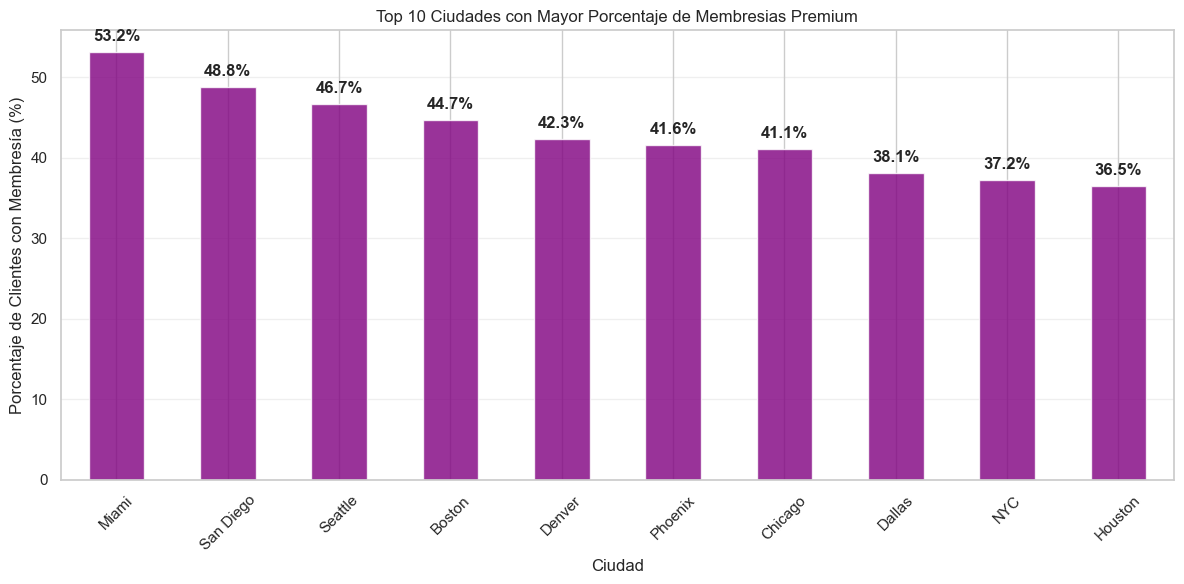

In [ ]:
# Ciudad con mas membresias
total_por_ciudad = df_clientes_completo['ciudad_residencia'].value_counts()
membresias_por_ciudad = df_clientes_completo[df_clientes_completo['membresia_premium'] == 'Sí']['ciudad_residencia'].value_counts()

# Calcular porcentaje
porcentaje_membresias = (membresias_por_ciudad / total_por_ciudad * 100).dropna().sort_values(ascending=False)

# Grafico de porcentaje
plt.figure(figsize=(12, 6))
porcentaje_membresias.head(10).plot(kind='bar', color='purple', alpha=0.8)
plt.title('Top 10 Ciudades con Mayor Porcentaje de Membresias Premium')
plt.ylabel('Porcentaje de Clientes con Membresía (%)')
plt.xlabel('Ciudad')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(porcentaje_membresias.head(10)):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\yaela\AppData\Local\Temp\ipykernel_21884\602592814.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['26-35', '36-45', '56-65', '36-45', '46-55', ..., '10-25', '66+', '66+', '66+', '56-65']
Length: 29692
Categories (6, object): ['10-25' < '26-35' < '36-45' < '46-55' < '56-65' < '66+']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  df_filtrado.loc[:, 'grupo_etario'] = pd.cut(df_filtrado['edad'],


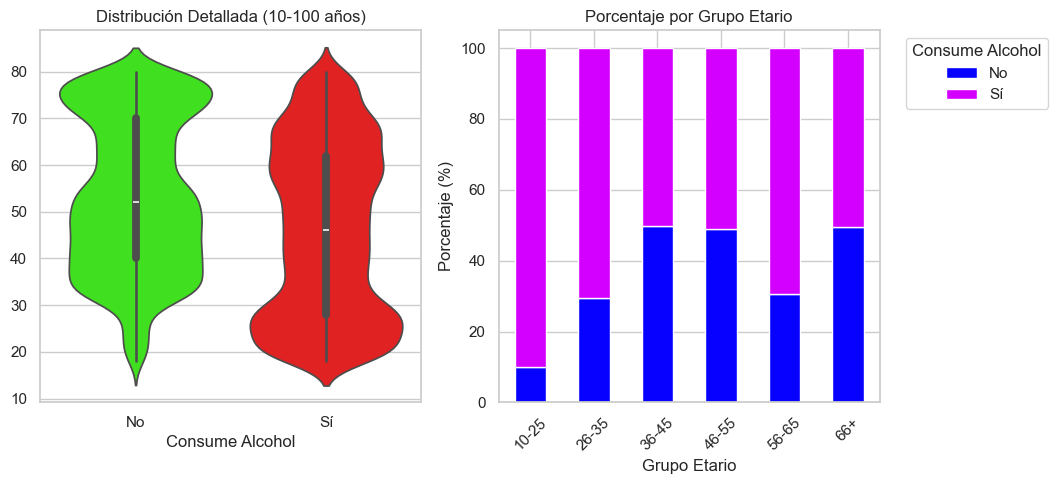

PRUEBA ESTADiSTICA - DIFERENCIA DE EDADES (10-100 años):
-------------------------------------------------------
Total personas analizadas: 29692
Personas que consumen alcohol: 18329
Personas que NO consumen alcohol: 11363

Edad promedio - Consumen: 46.0 años
Edad promedio - No consumen: 53.6 años
Diferencia: -7.7 años
Valor p: 0.0000
→ Diferencia estadísticamente significativa (p < 0.05)

ESTADISTICAS DESCRIPTIVAS:
------------------------------
                 count  mean   std   min   25%   50%   75%   max
consume_licor                                                   
No             11363.0  53.6  16.5  18.0  40.0  52.0  70.0  80.0
Sí             18329.0  46.0  18.5  18.0  28.0  46.0  62.0  80.0


In [24]:
# Relacion entre el consumo de alcohol vs edad
# Filtrar edades razonables (10-100 años) y crear copia explícita
df_filtrado = df_clientes_completo[(df_clientes_completo['edad'] >= 10) & 
                                  (df_clientes_completo['edad'] <= 100)].copy()

# Crear grupo etario usando .loc para evitar warnings
df_filtrado.loc[:, 'grupo_etario'] = pd.cut(df_filtrado['edad'], 
                                           bins=[10, 25, 35, 45, 55, 65, 100],
                                           labels=['10-25', '26-35', '36-45', '46-55', '56-65', '66+'])

# Análisis completo de consumo de alcohol vs edad
plt.figure(figsize=(15, 5))

# Subplot: Violin plot
plt.subplot(1, 3, 2)
sns.violinplot(data=df_filtrado, x='consume_licor', y='edad', 
               hue='consume_licor', palette=["#2bff00", "#ff0303"], 
               legend=False)
plt.title('Distribución Detallada (10-100 años)')
plt.xlabel('Consume Alcohol')
plt.ylabel('')

# Subplot: Porcentaje por grupo etario
plt.subplot(1, 3, 3)
consumo_por_edad = pd.crosstab(df_filtrado['grupo_etario'], 
                               df_filtrado['consume_licor'], 
                               normalize='index') * 100
consumo_por_edad.plot(kind='bar', stacked=True, color=["#0702ff", "#d400ff"], ax=plt.gca())
plt.title('Porcentaje por Grupo Etario')
plt.xlabel('Grupo Etario')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Consume Alcohol', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Analisis estadístico
print("PRUEBA ESTADiSTICA - DIFERENCIA DE EDADES (10-100 años):")
print("-" * 55)
edad_si = df_filtrado[df_filtrado['consume_licor'] == 'Sí']['edad']
edad_no = df_filtrado[df_filtrado['consume_licor'] == 'No']['edad']

print(f"Total personas analizadas: {len(df_filtrado)}")
print(f"Personas que consumen alcohol: {len(edad_si)}")
print(f"Personas que NO consumen alcohol: {len(edad_no)}")
print(f"\nEdad promedio - Consumen: {edad_si.mean():.1f} años")
print(f"Edad promedio - No consumen: {edad_no.mean():.1f} años")
print(f"Diferencia: {edad_si.mean() - edad_no.mean():.1f} años")

# Test t para muestras independientes
t_stat, p_value = stats.ttest_ind(edad_si, edad_no, nan_policy='omit')
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("→ Diferencia estadísticamente significativa (p < 0.05)")
else:
    print("→ No hay diferencia estadísticamente significativa")

# Estadísticas descriptivas
print("\nESTADISTICAS DESCRIPTIVAS:")
print("-" * 30)
print(df_filtrado.groupby('consume_licor')['edad'].describe().round(1))

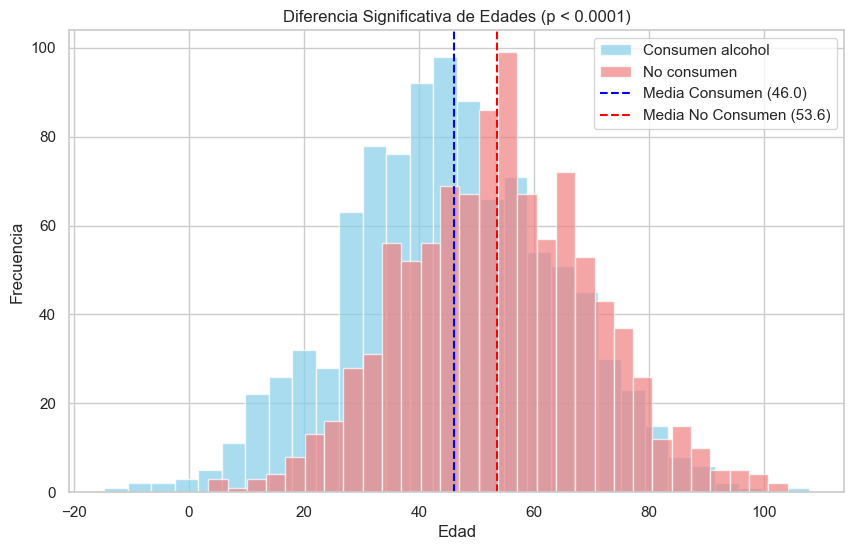

In [ ]:
# Visualizacion de la significancia estadistica
plt.figure(figsize=(10, 6))

# Datos de ejemplo para mostrar la diferencia
edades_consumen = np.random.normal(46.0, 18.5, 1000)
edades_no_consumen = np.random.normal(53.6, 16.5, 1000)

plt.hist(edades_consumen, alpha=0.7, label='Consumen alcohol', bins=30, color='skyblue')
plt.hist(edades_no_consumen, alpha=0.7, label='No consumen', bins=30, color='lightcoral')

plt.axvline(46.0, color='blue', linestyle='--', label='Media Consumen (46.0)')
plt.axvline(53.6, color='red', linestyle='--', label='Media No Consumen (53.6)')

plt.title('Diferencia Significativa de Edades (p < 0.0001)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

LISTADO: Distribucion por estratos SocioEconomicos
------------------------------------------------------------
*TODAS LAS CIUDADES:
   - Alto: 9038 personas (30.1%)
   - Bajo: 6161 personas (20.5%)
   - Medio: 9325 personas (31.1%)
   - Muy Alto: 5476 personas (18.3%)
*SOLO CHICAGO:
   - Alto: 1501 personas (29.6%)
   - Bajo: 874 personas (17.2%)
   - Medio: 1775 personas (35.0%)
   - Muy Alto: 919 personas (18.1%)

 GRÁFICO COMPARATIVO: ESTRATOS SOCIOECONÓMICOS


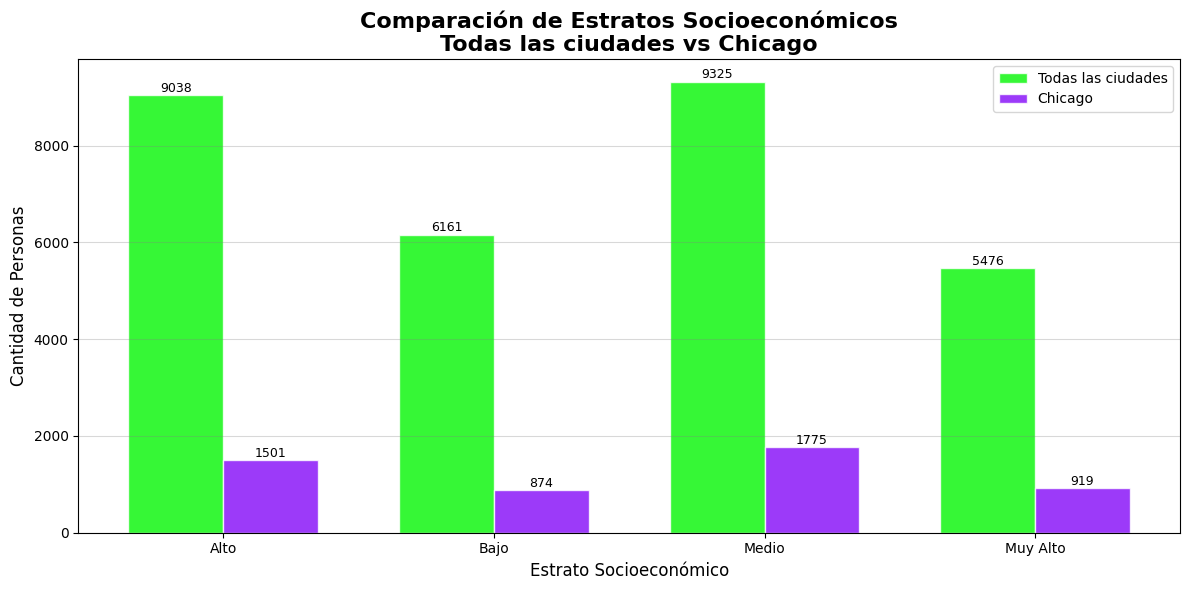

In [18]:
# Distribución por estratos socioeconómicos (TODAS las ciudades + CHICAGO)
#Objetivo: Analizar cómo se distribuyen los estratos socioeconómicos en:
# 1. Todas las ciudades del dataset
# 2. La ciudad de Chicago
#Para evaluar si Chicago es representativa en términos socioeconómicos.

print("LISTADO: Distribucion por estratos SocioEconomicos")
print("-" * 60)

if 'estrato_socioeconomico' in df_clientes_completo.columns:
    print("*TODAS LAS CIUDADES:")
    distribucion_estratos_total = df_clientes_completo['estrato_socioeconomico'].value_counts().sort_index()
    for estrato, count in distribucion_estratos_total.items():
        porcentaje = (count / len(df_clientes_completo)) * 100
        print(f"   - {estrato}: {count} personas ({porcentaje:.1f}%)")
    
    print("*SOLO CHICAGO:")
    if 'estrato_socioeconomico' in df_clientes_chicago.columns:
        distribucion_estratos_chicago = df_clientes_chicago['estrato_socioeconomico'].value_counts().sort_index()
        for estrato, count in distribucion_estratos_chicago.items():
            porcentaje = (count / len(df_clientes_chicago)) * 100
            print(f"   - {estrato}: {count} personas ({porcentaje:.1f}%)")


# Gráfico comparativo de estratos (TODAS vs CHICAGO) 
if 'estrato_socioeconomico' in df_clientes_completo.columns and 'estrato_socioeconomico' in df_clientes_chicago.columns:
    print("\n GRÁFICO COMPARATIVO: ESTRATOS SOCIOECONÓMICOS")
    
    plt.figure(figsize=(12, 6))
    
    # Preparar datos
    estratos_orden = sorted(df_clientes_completo['estrato_socioeconomico'].unique())
    valores_total = [distribucion_estratos_total.get(e, 0) for e in estratos_orden]
    valores_chicago = [distribucion_estratos_chicago.get(e, 0) for e in estratos_orden]
    
    x = np.arange(len(estratos_orden))
    width = 0.35
    
    # Barras en diferentes colores
    bars1 = plt.bar(x - width/2, valores_total, width, label='Todas las ciudades', 
                   color="#04F504", alpha=0.8, edgecolor='white')
    bars2 = plt.bar(x + width/2, valores_chicago, width, label='Chicago', 
                   color="#8408F8", alpha=0.8, edgecolor='white')
    
    plt.title('Comparación de Estratos Socioeconómicos\nTodas las ciudades vs Chicago', 
              fontsize=16, fontweight='bold', color='black')
    plt.xlabel('Estrato Socioeconómico', fontsize=12, color='black')
    plt.ylabel('Cantidad de Personas', fontsize=12, color='black')
    plt.xticks(x, estratos_orden, color='black')
    plt.yticks(color='black')
    plt.legend()
    plt.grid(axis='y', alpha=0.3, color='gray')
    plt.gca().set_facecolor('white')
    
    # Añadir valores en las barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9, color='black')
    
    plt.tight_layout()
    plt.show()

### La mayoría de los clientes se encuentra en los estratos Medio y Alto 
### Chicago refleja un patrón muy similar al total de ciudades

Gasto promedio y frecuencia por grupo etario


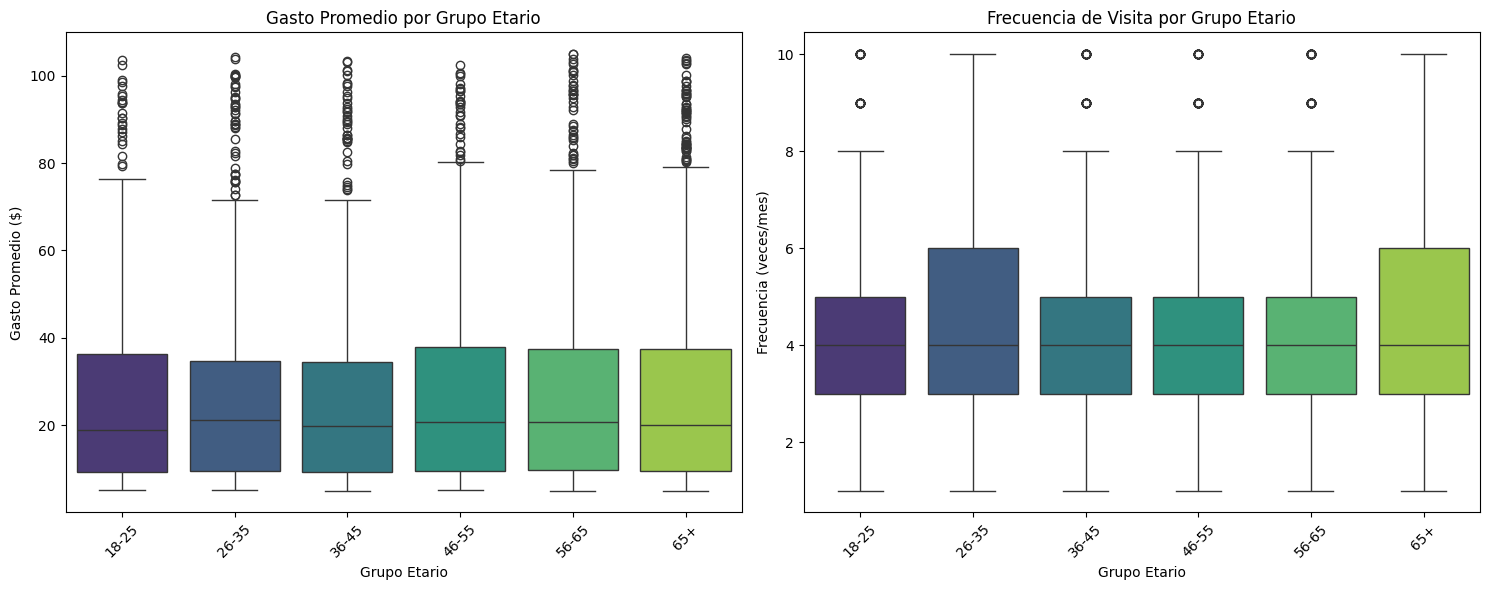

In [19]:
 # Ahora vamos a poner el Foco en Chicago

#Objetivo: Segmentar la base de clientes de Chicago por edad para identificar:
# 1. Diferencias en gasto promedio
# 2. Frecuencia de visitas por generacion
# 3. Preferencias de consumo para diseñar campañas personalizadas


 #  Crear grupos etarios a partir de la columna 'edad'
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_clientes_chicago['grupo_etario'] = pd.cut(df_clientes_chicago['edad'], bins=bins, labels=labels, right=False)

# Gasto promedio y frecuencia por grupo etario (boxplot)
print("Gasto promedio y frecuencia por grupo etario")
plt.figure(figsize=(15, 6))

# Gasto promedio por grupo etario
plt.subplot(1, 2, 1)
sns.boxplot(data=df_clientes_chicago, x='grupo_etario', y='promedio_gasto_comida', hue='grupo_etario', palette='viridis', legend=False)
plt.title('Gasto Promedio por Grupo Etario')
plt.xlabel('Grupo Etario')
plt.ylabel('Gasto Promedio ($)')
plt.xticks(rotation=45)

# Frecuencia de visita por grupo etario
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clientes_chicago, x='grupo_etario', y='frecuencia_visita', hue='grupo_etario', palette='viridis', legend=False)
plt.title('Frecuencia de Visita por Grupo Etario')
plt.xlabel('Grupo Etario')
plt.ylabel('Frecuencia (veces/mes)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Preferencias alimenticias por grupo etario


<Figure size 1200x800 with 0 Axes>

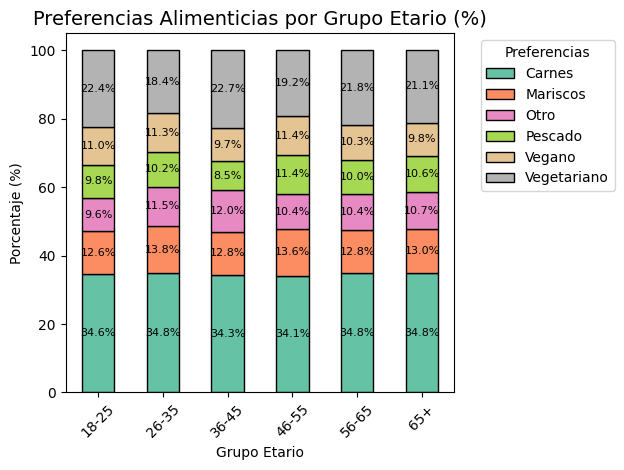

In [20]:
# Preferencias alimenticias por grupo etario
print("Preferencias alimenticias por grupo etario")

# Crear tabla cruzada de preferencias por grupo etario
preferencias_etario = pd.crosstab(df_clientes_chicago['grupo_etario'], 
                                 df_clientes_chicago['preferencias_alimenticias'])

# Calcular porcentajes
preferencias_etario_pct = preferencias_etario.div(preferencias_etario.sum(axis=1), axis=0) * 100

# Ordenar grupos etarios según bins originales
orden_etario = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
preferencias_etario_pct = preferencias_etario_pct.reindex(orden_etario)

# Graficar
plt.figure(figsize=(12, 8))
ax = preferencias_etario_pct.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black')

plt.title('Preferencias Alimenticias por Grupo Etario (%)', fontsize=14)
plt.xlabel('Grupo Etario')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45)
plt.legend(title='Preferencias', bbox_to_anchor=(1.05, 1), loc='upper left')

# Agregar porcentajes en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

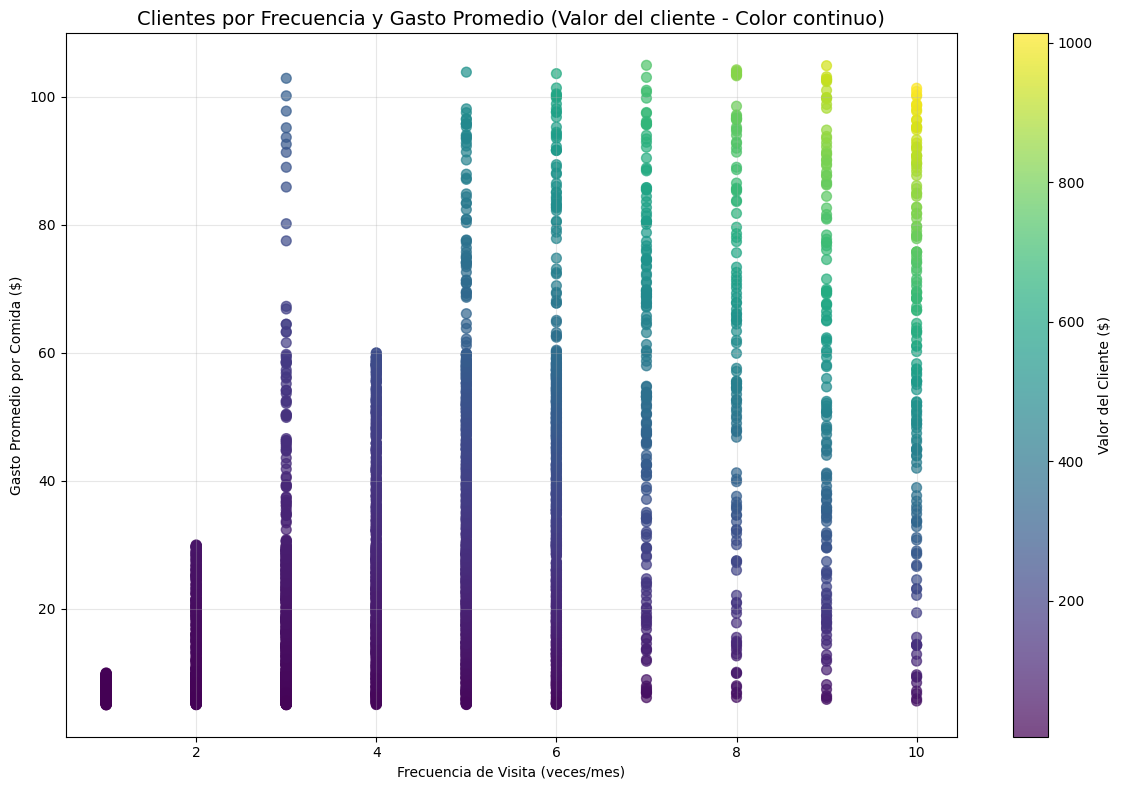

In [21]:
# Grafico: Relacion de frecuencia de visita vs gasto por estrato

# Primero vamos a calcular un valor cliente entre diferentes variables
df_clientes_chicago['valor_cliente'] = df_clientes_chicago['frecuencia_visita'] * df_clientes_chicago['promedio_gasto_comida']

# Ahora a por el grafico
plt.figure(figsize=(12,8))

sc = plt.scatter(
    df_clientes_chicago['frecuencia_visita'],
    df_clientes_chicago['promedio_gasto_comida'],
    c=df_clientes_chicago['valor_cliente'],  
    cmap='viridis',
    s=50,
    alpha=0.7
)

plt.colorbar(sc, label='Valor del Cliente ($)')
plt.title('Clientes por Frecuencia y Gasto Promedio (Valor del cliente - Color continuo)', fontsize=14)
plt.xlabel('Frecuencia de Visita (veces/mes)')
plt.ylabel('Gasto Promedio por Comida ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Sumemos un Analisis Estadistico de Estrato Socioeconomico
print("\nEstadisticas por estrato socioeconómico (Chicago):")
print("-" * 60)

estratos_stats = df_clientes_chicago.groupby('estrato_socioeconomico').agg({
    'frecuencia_visita': ['mean', 'median', 'count'],
    'promedio_gasto_comida': ['mean', 'median'],
    'ingresos_mensuales': 'mean',
    'valor_cliente': 'mean'
}).round(2)

print(estratos_stats)


Estadisticas por estrato socioeconómico (Chicago):
------------------------------------------------------------
                       frecuencia_visita              promedio_gasto_comida  \
                                    mean median count                  mean   
estrato_socioeconomico                                                        
Alto                                4.91    5.0  1501                 32.55   
Bajo                                2.07    2.0   874                  7.53   
Medio                               3.53    3.0  1775                 17.47   
Muy Alto                            7.23    7.0   919                 54.17   

                              ingresos_mensuales valor_cliente  
                       median               mean          mean  
estrato_socioeconomico                                          
Alto                    32.97            6208.85        159.47  
Bajo                     7.54            1193.10         15.70  
Medio   

### La frecuencia y el gasto promedio aumentan con el estrato socioeconómico, lo que permite segmentar campañas según poder adquisitivo y hábitos de consumo.

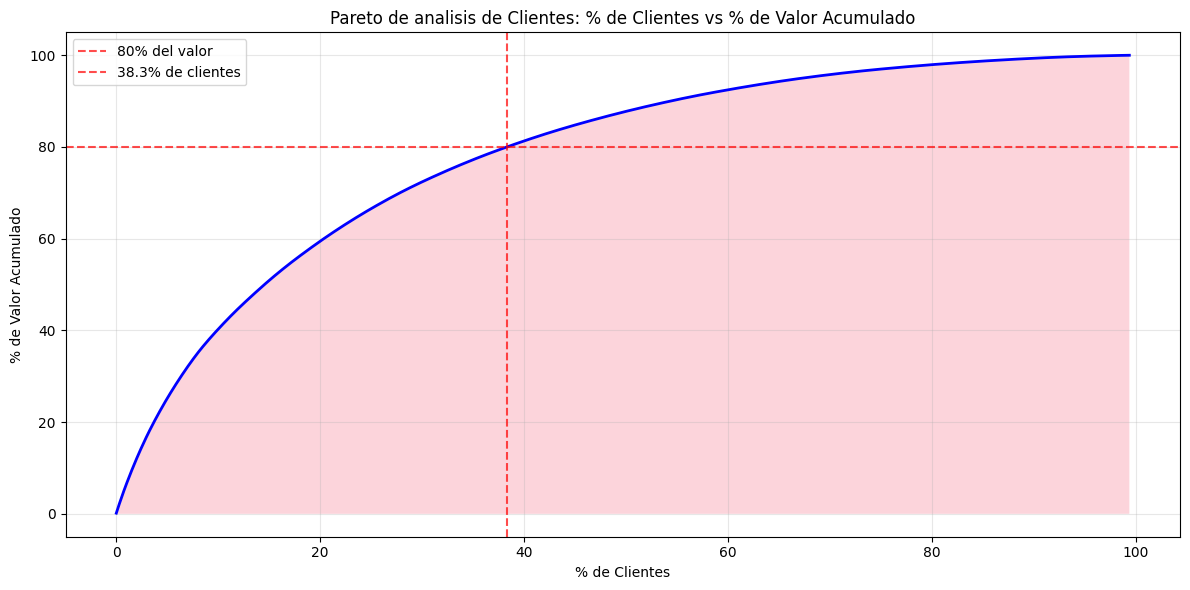

El 38.3% de los clientes genera el 80% del valor total


In [23]:
# Vamos a hacer un Analisis del Valor del Cliente 

#Objetivo: Medir el Valor del Cliente mediante una metrica combinada que refleje la importancia de cada cliente para el negocio, considerando:
# Valor del Cliente = Frecuencia de Visita × Gasto Promedio
# Esto permite identificar clientes de alto valor y orientar estrategias de fidelización y mkt personalizado

# Pareto (80/20): clientes que mas gastan vs % acumulado del total

# Ordenar clientes por valor descendente
clientes_ordenados = df_clientes_chicago.sort_values('valor_cliente', ascending=False)
clientes_ordenados['valor_acumulado'] = clientes_ordenados['valor_cliente'].cumsum()
clientes_ordenados['porcentaje_acumulado'] = clientes_ordenados['valor_acumulado'] / clientes_ordenados['valor_cliente'].sum() * 100
clientes_ordenados['porcentaje_clientes'] = (np.arange(len(clientes_ordenados)) + 1) / len(clientes_ordenados) * 100

# Encontrar punto donde se alcanza el 80% del valor
punto_80 = clientes_ordenados[clientes_ordenados['porcentaje_acumulado'] >= 80].iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(clientes_ordenados['porcentaje_clientes'], clientes_ordenados['porcentaje_acumulado'], color='blue', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% del valor')
plt.axvline(x=punto_80['porcentaje_clientes'], color='red', linestyle='--', alpha=0.7, 
            label=f'{punto_80["porcentaje_clientes"]:.1f}% de clientes')
plt.fill_between(clientes_ordenados['porcentaje_clientes'], 0, clientes_ordenados['porcentaje_acumulado'], alpha=0.3)

plt.title('Pareto de analisis de Clientes: % de Clientes vs % de Valor Acumulado')
plt.xlabel('% de Clientes')
plt.ylabel('% de Valor Acumulado')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"El {punto_80['porcentaje_clientes']:.1f}% de los clientes genera el 80% del valor total")

### Esto indica que una minoria de clientes aporta la mayor parte de los ingresos, estas personas son el segmento prioritario para campañas de fidelización, upselling y promociones exclusivas.
### Permite enfocar recursos en los clientes mas valiosos y aumentar la eficiencia de las acciones de marketing.

In [24]:
# Filtrar clientes que acumulan hasta el 80% del valor
# Vamos a guardar esta segmentacion para enfocar campañas en esa base
clientes_top_80 = clientes_ordenados[clientes_ordenados['porcentaje_acumulado'] <= 80]

# Guardar en CSV dentro de la carpeta Archivos CSV
ruta_guardado = "../Archivos_CSV/clientes_top_80-20.csv"
clientes_top_80.to_csv(ruta_guardado, index=False)
print(f"Archivo guardado en: {ruta_guardado}")

print(f"Archivo guardado con {len(clientes_top_80)} clientes en: {ruta_guardado}")

Archivo guardado en: ../Archivos_CSV/clientes_top_80-20.csv
Archivo guardado con 1942 clientes en: ../Archivos_CSV/clientes_top_80-20.csv


## Ahora sigamos con el archivo Yelp
Objetivo general:
Analizar los datos de restaurantes para generar insights que apoyen la estrategia de segmentacion de campañas de marketing. Esto incluye identificar patrones de consumo, oportunidades de colaboración con negocios locales y tendencias de mercado que permitan diseñar campañas más efectivas y personalizadas.

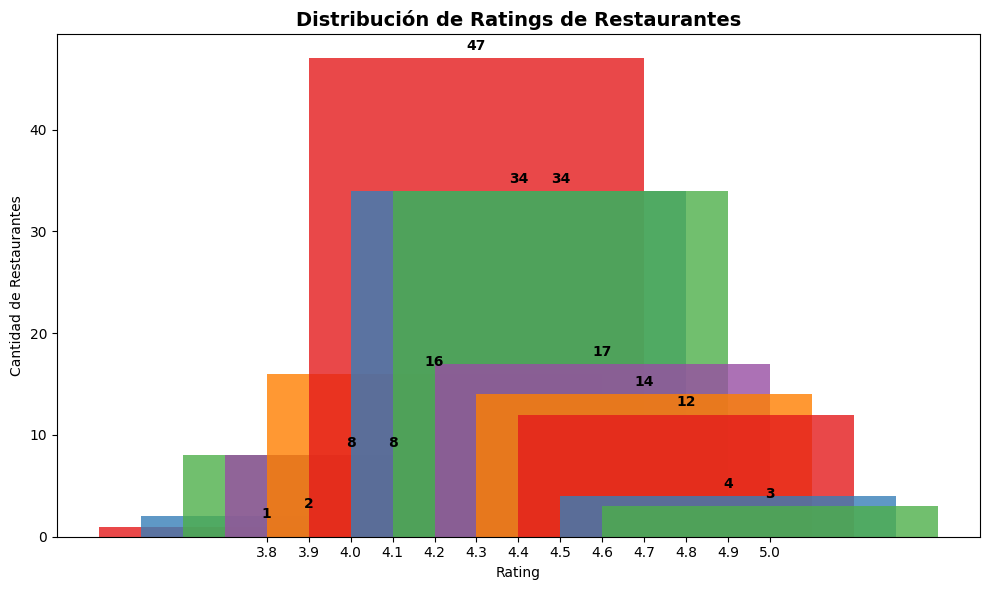

In [25]:
#Distribución de ratings
# Comprender como se distribuyen las calificaciones de los restaurantes ayuda a detectar brechas de calidad, identificar segmentos con mayor potencial de engagement y orientar decisiones sobre posicionamiento de productos y mensajes de marketing.

plt.figure(figsize=(10, 6))
rating_counts = df_restaurantes['rating'].value_counts().sort_index()

# Paleta de colores contrastante
colores = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']  # rojo, azul, verde, violeta, naranja

plt.bar(rating_counts.index, rating_counts.values, color=colores[:len(rating_counts)], alpha=0.8)
plt.title('Distribución de Ratings de Restaurantes', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Cantidad de Restaurantes')
plt.xticks(rating_counts.index)

# Añadir valores sobre las barras
for i, v in enumerate(rating_counts.values):
    plt.text(rating_counts.index[i], v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')
    
plt.tight_layout()
plt.show()

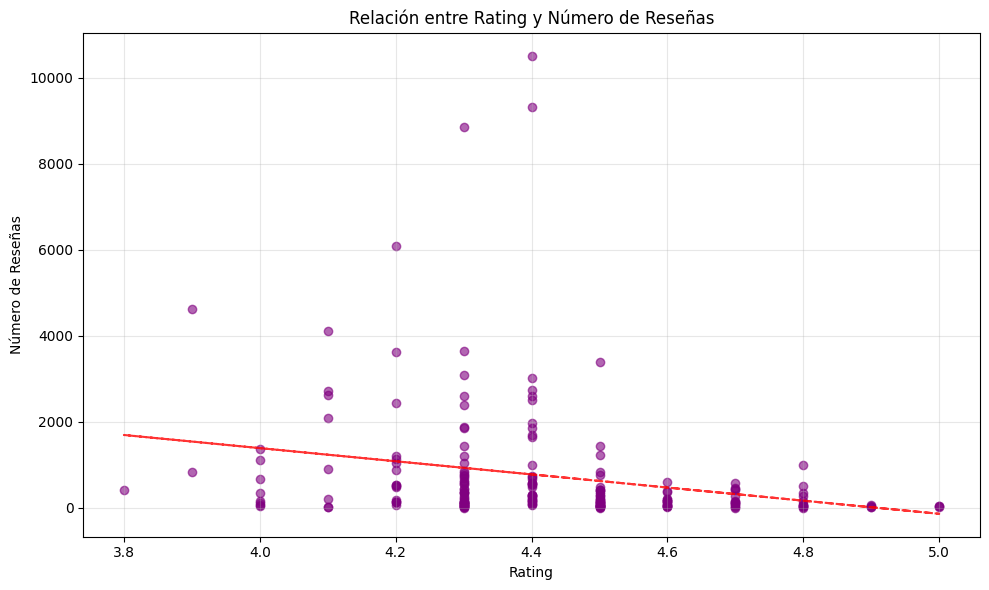

In [26]:
#Rating vs número de reseñas: para explorar si existe una relación entre la calificación de los restaurantes y su popularidad
# Esto permite identificar patrones de visibilidad y reputación que pueden influir en la efectividad de campañas

plt.figure(figsize=(10, 6))
plt.scatter(df_restaurantes['rating'], df_restaurantes['reseñas'], alpha=0.6, color='purple')

# Calcular y mostrar línea de tendencia
z = np.polyfit(df_restaurantes['rating'], df_restaurantes['reseñas'], 1)
p = np.poly1d(z)
plt.plot(df_restaurantes['rating'], p(df_restaurantes['rating']), "r--", alpha=0.8)

plt.title('Relación entre Rating y Número de Reseñas')
plt.xlabel('Rating')
plt.ylabel('Número de Reseñas')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

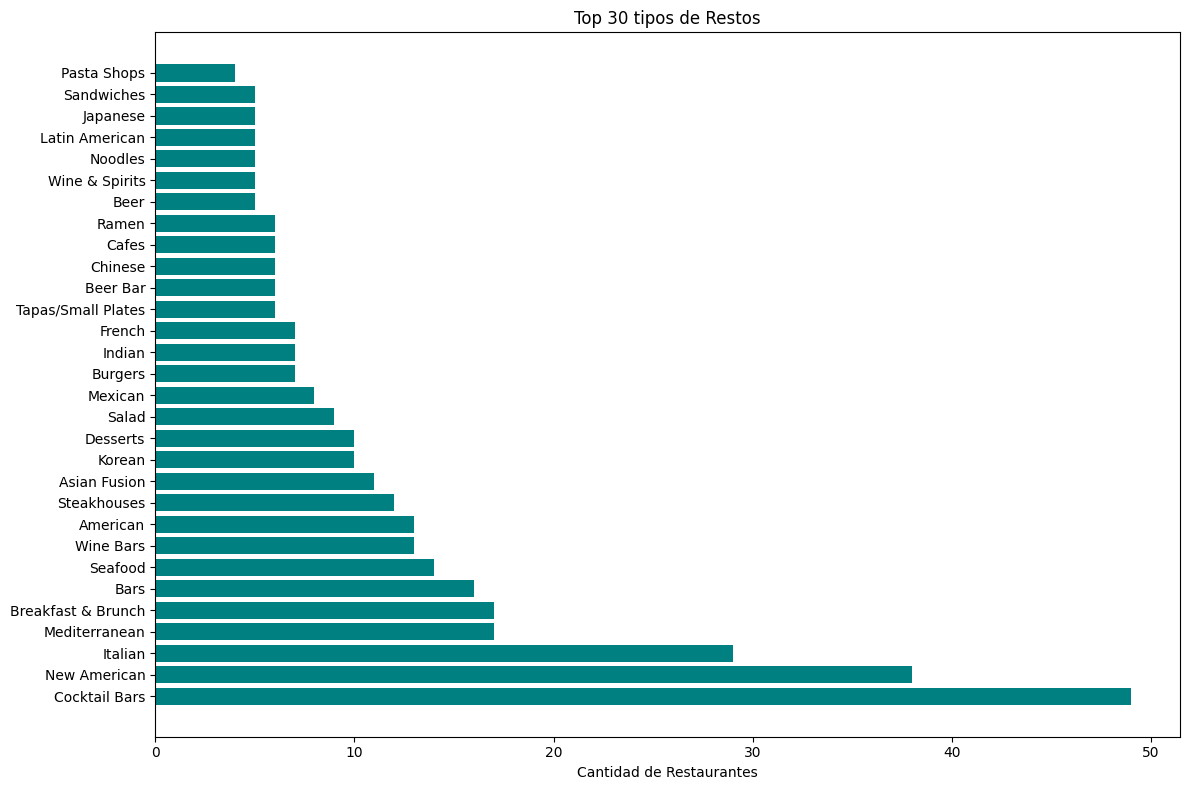

In [27]:
# Veamos el Top de Categorias de Restaurantes en Yelp
# Para entender las tendencias del mercado y oportunidades de nicho.

# Primero vamos a separar categorias, ya que estaban en formato string, separadas por comas
todas_categorias = []
for categorias in df_restaurantes['categorias'].dropna():
    if isinstance(categorias, str):
        # Separar por comas y limpiar espacios
        cats = [cat.strip() for cat in categorias.split(',')]
        todas_categorias.extend(cats)

# Contar frecuencia de categorías
from collections import Counter
contador_categorias = Counter(todas_categorias)

# Tomar las 30 categorías más comunes
top_categorias = contador_categorias.most_common(30)

plt.figure(figsize=(12, 8))
plt.barh([cat[0] for cat in top_categorias], [cat[1] for cat in top_categorias], color='teal')
plt.title('Top 30 tipos de Restos')
plt.xlabel('Cantidad de Restaurantes')
plt.tight_layout()
plt.show()

Encontrados 36 restaurantes con alto rating (≥4.5) pero baja visibilidad (≤81 reseñas)


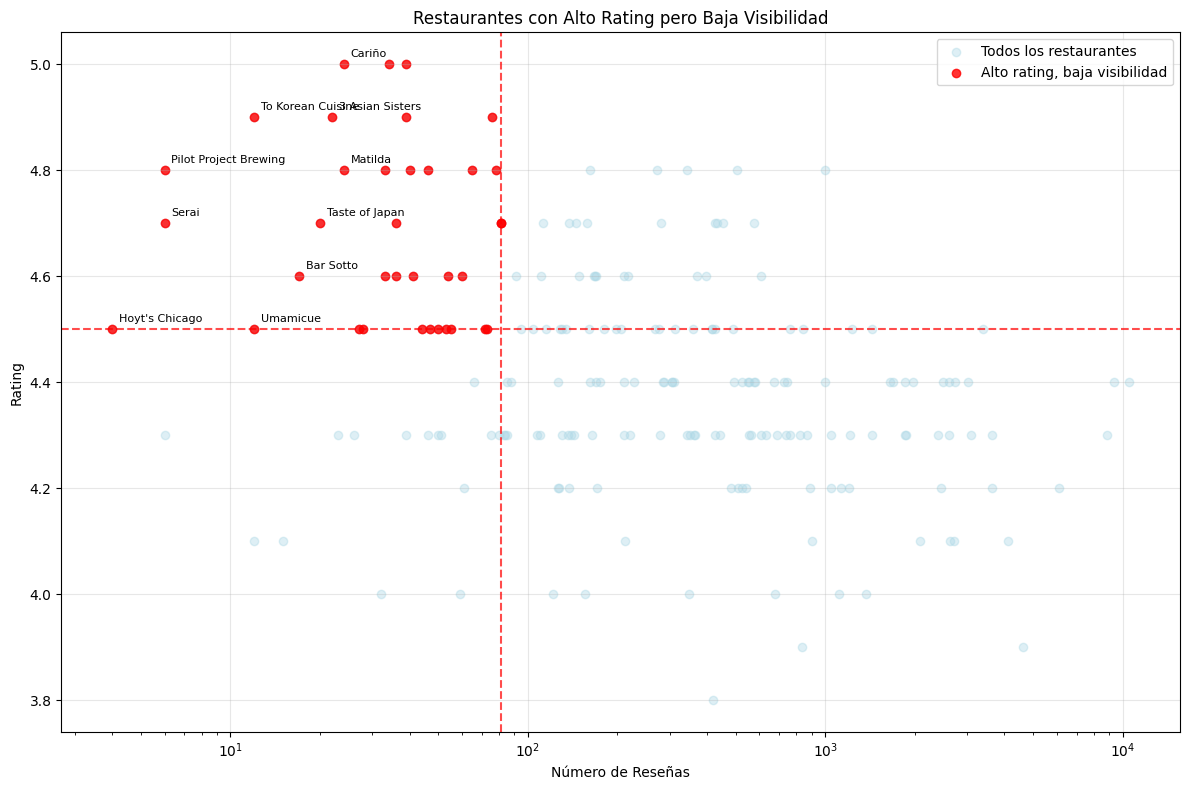

In [28]:
#Insight destacado: "restaurantes con alto rating pero baja visibilidad"
# Buscamos detectar restaurantes que mantienen una alta calidad segun su calificación, pero que tienen baja visibilidad en el mercado (pocas reseñas). 
# Estos negocios representan oportunidades estrategicas de colaboración: 
# al apoyarlos con campañas de marketing o promociones, se puede incrementar su exposicion, fortalecer relaciones y generar valor 

# Definir umbrales: alto rating (≥4.5) y baja visibilidad (percentil 25 inferior de reseñas)
umbral_rating = 4.5
umbral_resenas = df_restaurantes['reseñas'].quantile(0.25)

# Filtrar restaurantes
alto_rating_baja_visibilidad = df_restaurantes[
    (df_restaurantes['rating'] >= umbral_rating) & 
    (df_restaurantes['reseñas'] <= umbral_resenas)
]

print(f"Encontrados {len(alto_rating_baja_visibilidad)} restaurantes con alto rating (≥{umbral_rating}) pero baja visibilidad (≤{umbral_resenas:.0f} reseñas)")

# Crear scatter plot
plt.figure(figsize=(12, 8))

# Todos los restaurantes
plt.scatter(df_restaurantes['reseñas'], df_restaurantes['rating'], 
            alpha=0.4, color='lightblue', label='Todos los restaurantes')

# Destacar los de alto rating pero baja visibilidad
plt.scatter(alto_rating_baja_visibilidad['reseñas'], alto_rating_baja_visibilidad['rating'], 
            alpha=0.8, color='red', label='Alto rating, baja visibilidad')

# Añadir líneas de umbral
plt.axhline(y=umbral_rating, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=umbral_resenas, color='red', linestyle='--', alpha=0.7)

# Añadir anotaciones para algunos restaurantes destacados
top_destacados = alto_rating_baja_visibilidad.sort_values(by='reseñas').head(10)

for _, restaurante in top_destacados.iterrows():
    plt.annotate(restaurante['nombre_negocio'], 
                 (restaurante['reseñas'], restaurante['rating']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
plt.xscale('log')
plt.title('Restaurantes con Alto Rating pero Baja Visibilidad')
plt.xlabel('Número de Reseñas')
plt.ylabel('Rating')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Continuamos en el archivo de RECOMENDACIONES, y para mas informacion sobre los pasos realizados, consulte el README del proyecto donde se detallan todos los pasos.
